In [33]:
# Alex Medina
# AST 5765
# Homework 6
# 26 September 2025

In [34]:
# General libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [36]:
print('Problem 2 \n')

print('Completed and added as a pdf. \n')

Problem 2 

Completed and added as a pdf. 



In [37]:
print('Problem 3a \n')

Problem 3a 



In [ ]:
# Opening the file with pandas
file  = r"hw6_synthetic_transit_lightcurve.csv"
lc_df = pd.read_csv(file)

X     = lc_df['Time (days)']     # Time array
Y     = lc_df['Normalized Flux'] # Flux

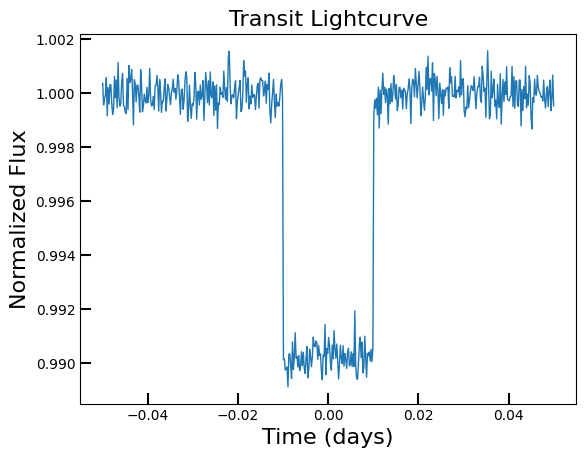

In [47]:
# Plotting
plt.figure()
plt.plot(X, Y, linewidth=1)

# Labels
plt.title('Transit Lightcurve', fontsize = 16)
plt.xlabel('Time (days)', fontsize = 16)
plt.ylabel('Normalized Flux', fontsize = 16)
plt.tick_params(axis='both', which='major', length=8, width=1.5, direction='in')
plt.show()

In [48]:
print('Problem 3b \n')

Problem 3b 



In [49]:
# i

def windowfit(x, center, width, height):
    """
    Takes as input x array.
    Returns the data of x centered at center
    """
    half = 0.5 * width
    mask = np.abs(x - center) <= half
    y = np.ones_like(x)
    y[mask] -= height
    return y

print('Window fit function created. \n')

Window fit function created. 



C:\Users\Alex\AppData\Local\Temp\ipykernel_21308\2966216216.py:10: OptimizeWarning: Covariance of the parameters could not be estimated
  (fit, cov_x) = curve_fit(windowfit, X, Y, p0=p0)


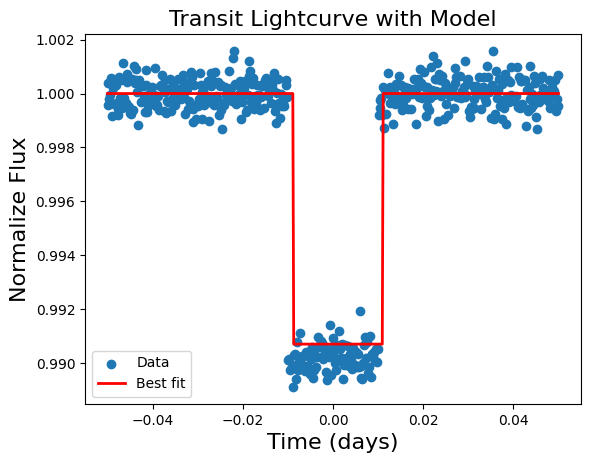

In [50]:
# ii

# Initial guesses (trial and error)
c0 = X[np.argmin(Y) + 50]           # Center guess
w0 = 0.2 * (np.max(X) - np.min(X))  # Width guess
h0 = 1.0 - np.min(Y)                # Height guess
p0=[c0, w0, h0]

# Curve fit
(fit, cov_x) = curve_fit(windowfit, X, Y, p0=p0)
fiterr = np.sqrt(np.diag(cov_x))

# Plot fit over data
plt.figure()
plt.scatter(X, Y, lw=1, label="Data")
plt.plot(X, windowfit(X, *fit), lw=2, color='red', label="Best fit")
plt.title('Transit Lightcurve with Model', fontsize = 16)
plt.xlabel('Time (days)', fontsize = 16)
plt.ylabel('Normalize Flux', fontsize = 16)
plt.legend()
plt.show()

In [54]:
# iii

# The best fit
t_fit, w_fit, h_fit = fit
print('Best-fit parameters:')
print('Center Fit = {0:.4f}'.format(t_fit))
print('Width Fit = {0:.4f}'.format(w_fit))
print('Height Fit = {0:.4f}'.format(h_fit))

# Depth of transit is (Rpl/Rstar)^2
# So Rpl/Rstar = root(depth)
# And Rpl = Rstar * root(depth)

Rstar = 1.14     # Stellar radius of 1.14
Depth = fit[2]   # Height since norm flux
Rpl   = Rstar * np.sqrt(Depth)

print('\nIf we have an Rstar of 1.14 R0, then the')
print(f'Exoplanet radius = {Rpl:.4f} R0. \n')

Best-fit parameters:
Center Fit = 0.0011
Width Fit = 0.0200
Height Fit = 0.0093

If we have an Rstar of 1.14 R0, then the
Exoplanet radius = 0.1099 R0. 



In [55]:
print('Problem 3c \n')

Problem 3c 



In [57]:
Rstar, Rstar_err = 1.14, 0.01 # in R0
Depth, Depth_err = fit[2], 0.002

# Planet radius
Rpl   = Rstar * np.sqrt(Depth)

# Error propagation
par1 = np.sqrt(Depth)
par2 = Rstar * (1/2) * (Depth)**(-1/2)

Rpl_err = np.sqrt( (Rstar_err * par1)**2 + (Depth_err * par2)**2 )

print('Rpl = {0:.4f} +- {1:.4f}'.format(Rpl, Rpl_err))
print('So the error in planetary radius = {0:.4f}'.format(Rpl_err))

Rpl = 0.1099 +- 0.0119
So the error in planetary radius = 0.0119
